# ▶️ Initialisation
⚠️ Require Pubchem API, therefore, internet 🌐

 ## 📖 libraries

In [418]:
import numpy as np
import pandas as pd

# =============================================
# Core Scientific/LCA (Life Cycle Assessment) Libraries
# Required for Brightway2.5 (LCA framework)
# Always place these at the top, as they are the main dependencies for your project
# =============================================
import os
import bw2io as bi # Brightway library for data import/export
import bw2data as bd # Core Brightway library for LCA database management
import bw2calc as bc

# =============================================
# Data Processing and Numerical Libraries
# Used for data manipulation, math, and array operations
# =============================================
import numpy as np  # Numerical computing (arrays, math operations), only version for np.nan # numpy==1.26.4
import pandas as pd # Data manipulation and analysis (DataFrames)
import math         # Basic math functions
import csv          # CSV file reading/writing
import os           # Operating system interfaces (file paths, environment variables)
import re           # Regular expressions (text pattern matching)

# =============================================
# File System and Path Handling
# Used for file and directory operations
# =============================================
from pathlib import Path  # Object-oriented filesystem paths

# =============================================
# Time and Delay Utilities
# Used for introducing delays or measuring time
# =============================================
from time import sleep  # Introduce delays (e.g., for web scraping)
import time             # Time-related functions (e.g., `time.time()`)

# =============================================
# Chemistry and Data Retrieval
# Used for chemical data and external API access
# =============================================
import pubchempy as pcp                 # Interface to PubChem (chemical data)
from pubchempy import PubChemHTTPError  # Unique CF assignment for each flow that contains copper
import requests                         # HTTP requests (e.g., API calls)
from mendeleev import element           # Periodic table data (element properties)

## brightway

In [419]:
# Set up the project and database
project_name = "CERC" # Name of the project, choose wisely according to list(bd.projects)
bd.projects.set_current(project_name)

# Retrieves credentials that are stored in the os.
username = os.getenv("EI_USERNAME")
password = os.getenv("EI_PASSWORD")

# Use this code if the project is not imported yet
#bi.import_ecoinvent_release("3.4", "cutoff", username, password)

# 1. Initialize the database object
biosphere_db = bd.Database('ecoinvent-3.4-biosphere')

bd.databases

Databases dictionary with 2 object(s):
	ecoinvent-3.4-biosphere
	ecoinvent-3.4-cutoff

In [420]:
bd.projects.set_current("CERC")

### bw project managment

In [421]:
# backup_dir = r"C:\Users\louis\.github\Exergy-Ore-Grade-Decrease-Model\bw_backups"
# bi.backup.backup_project_directory(
#     project=bd.projects.current,
#     dir_backup=backup_dir 
# )

# # Path to your backup file
# backup_path = Path(r"C:\Users\louis\.github\Exergy-Ore-Grade-Decrease-Model\bw_backups\brightway2-project-CERC-backup31-July-2026-01-18AM.tar.gz")

# # Create a new project name (clean, uncorrupted)
# new_project_name = "CERC_workflow"

# print(f"Restoring backup to new project: {new_project_name}")
# print(f"Backup file: {backup_path}")
# print(f"Backup exists: {backup_path.exists()}")

# # Restore the backup as a new project
# try:
#     restored_name = bi.backup.restore_project_directory(
#         fp=str(backup_path),
#         project_name=new_project_name,
#         overwrite_existing=False,  # Don't overwrite if exists
#         switch=True  # Switch to this project after restore
#     )
#     print(f"\n✓ Project successfully restored as: {restored_name}")
#     print(f"Current project: {bd.projects.current}")
    
# except Exception as e:
#     print(f"Error during restore: {e}")
#     print("\nTrying alternative method...")

## 💾 Vieira Ore grade decline variables

* In depht method ➡️ Vieira et al. (2012) 🪢 https://repository.ubn.ru.nl/handle/2066/103594
* In depht data ➡️ Vieira et al. (2016) 
    supporting information 🪢 https://onlinelibrary.wiley.com/action/downloadSupplement?doi=10.1111%2Fjiec.12444&file=jiec12444-sup-0001-SuppMat.pdf
    article for URR, A, and CME 🪢 https://doi.org/10.1111/jiec.12444

In [422]:
viera_csv_input_data = "inputs/sop-vieira-constants_all.csv" # 🤖 can be "inputs/sop-vieira-constants_all.csv"  or "inputs/sop-vieira-constants_updatedFe.csv" 

## 💾 Valero Data

In [423]:
valero_csv_input_data = "inputs/valero-constants_with_xm.csv"

## parameter cells

In [424]:
# PARAMETERS (inject these)
viera_csv_input_data = "inputs/sop-vieira-constants_updatedFe.csv" # (a) "inputs/sop-vieira-constants_all.csv" or (b) "inputs/sop-vieira-constants_updatedFe.csv"
valero_csv_input_data = "inputs/valero-constants.csv"
input_for_xi = valero_csv_input_data # (1) valero_csv_input_data or (2) viera_csv_input_data
focus = "dissipation"  # (i)"natural_resources" or (ii) "dissipation"

In [425]:
parameter_code = "b1ii" 

#### Tested:
2026-08-10:  

            a2ii, b1ii, b2ii, b1i, b2i, a2i, a1i  
            Note: a1i > a2i > b1i > b2i  
            (a) CF2: Iron is no accounted for.  
                CF1: Iron ores are of more less OGD since Iron is not accounted

# ⏳ Marginalist Perspective (similar to Hierarchist cultural perspective)

## Step 1: Calcul the CF1

From:
    📖 Viera et al. (2012), Ore grade decrease as life cycle impact indicator for metal scarcity: The case of copper
    🪢 https://repository.ubn.ru.nl/handle/2066/103594

A loglogistic relationship between cumulative metal tonnage extracted and ore grade:

$CMT_{g_i} = \frac{A}{1+ exp(\frac{ln(g_i)-\alpha}{\beta})}$

where $CMT$ is the cumulative metal tonnage extracted up to a certain ore grade $g$ (megaton). $A$ is the reserve estimate of metal available for mining (megaton), $g$ is the ore grade (\%), $i$ is an index representing each mining site, $α$ is the location parameter, and $β$ is the scale parameter of the loglogistic distribution. 

The ore grade as a function of the cumulative metal tonnage extracted can be obtained:

$g_{CMT,i}=exp(\alpha)\cdot (\frac{A}{CMT_i}-1)^\beta$

When CMT and A are expressed in mega tons, the CF becomes in $\%.kg^{-1}$ extracted:

$CF = -\frac{\delta g}{\delta CMT} = -g' = \frac{A \beta e^\alpha }{CMT\cdot(A-CMT)}(\frac{A}{CMT}-1)^\beta$ (Viera et al. (2012) Formula)

↔️ $CF_1(Me) = \frac{\partial g}{\partial CMT} = -\frac{A \beta e^{\alpha}}{CMT^2}(\frac{A}{CMT}-1)^{\beta - 1}\\$

For the elementary flows (EF):

$CF_1(EF) = \sum [ (n_i * \frac{aw_i}{mw_M} * CF_1(E_i) ]$ for all $E_i$ computed with $CF_1(Me)$

### Functions

#### 🧪 compound elemental compositions

In [426]:
# 1. The name of each flow will be cleaned using re
def clean_chemical_name(name):
    # This detects some of the organic molecules (e.g. Ethane, 1,1-difluoro-, HFC-152a)
    pattern1 = r"^(.+?),\s+(.+?)-(?:,\s+.*|$)"
    # This pattern simple detects the flows with a comma.
    pattern2 = r"(?<=[a-zA-Z]),.*"

    # First, check if the flow satisfies pattern1
    match = re.search(pattern1,name)
    # If there is a match, then we change its format (e.g. from Ethane, 1,1-difluoro-, HFC-152a to 1,1-difluoroEthane)
    if match:
        name = re.sub(pattern1, r"\g<2>\g<1>", name)
    # If not, we apply the 2nd pattern
    else:
        name = re.sub(pattern2, "", name)
    
    # Second, remove Roman numerals at the end (e.g., Aluminium III -> Aluminium) if applicable
    name = re.sub(r"\s+[IVXLCDM]+$", "", name)
    
    # 3. Third the word 'ion' or 'ions' at the end (e.g., Copper ion -> Copper) if applicable
    # Using re.IGNORECASE makes it catch 'Ion', 'ION', or 'ion'
    name = re.sub(r"\s+ions?$", "", name, flags=re.IGNORECASE)
    
    return name.strip()

# 2. Then, it will be fed to the API to find the chemical. If it is found, the original flow name, the chemical IUPAC name, molecular composition, and the molecular weight will be made into a dictionary
def chem_comp(mf):
    # First of all, we need to use re to cut the molecular formula into pieces
    # Regex breakdown:
    # ([A-Z][a-z]?) -> Matches an Uppercase letter potentially followed by a lowercase (the element)
    # (\d*)         -> Matches zero or more digits following the element (the count)
    pattern = r"([A-Z][a-z]?)(\d*)"
    
    matches = re.findall(pattern, mf)
    
    parts = []

    for elem,count in matches:
        # If the count is empty (like in 'Cl'), it means there is 1 atom
        count = int(count) if count else 1
        parts.append([elem,count])
    
    return parts

# Added here a dict input to switch between CF1 and CF2 dictionaries
def has_elem(parts,dict): 
    for elem, count in parts:
        if elem not in dict.keys(): #if it is not included in the list of elements
            print(f"{elem} is not included in the scope.")
            continue
        else:
            return True
    return None

# 3. Calculates for the CF of the given molecular formular
# Added here a dict input to switch between CF1 and CF2 dictionaries
def cf_calculator(dict,mw,parts):
    cf=0 # place holder for the 
    for elem, count in parts:
        if elem in dict.keys():
            # Find the atomic mass of the element first
            el_data = element(elem) # from mendeley library
            # Robustly get atomic weight as a scalar float (handles numpy/pandas types)
            aw = getattr(el_data, "atomic_weight", None)
            if aw is None:
                raise ValueError(f"No atomic_weight for element {elem}")
            # If it's a pandas Series or similar, take first element
            if hasattr(aw, "iloc"):
                aw = aw.iloc[0]
            # If it's array-like (numpy), take first element
            elif hasattr(aw, "__array__") and not isinstance(aw, (float, int, str)):
                aw = aw[0]
            mass = float(aw)
            if mass == 0:
                raise ValueError(f"Atomic weight for {elem} is zero")
            # Compute for the contribution of this element in the final mf
            cf += count*(mass/mw)*dict[elem]
        else:
            continue
    return cf

#### ✅ validity input data

In [427]:
def check_resource_limits(csv_file):
    """
    Check the physical and mathematical consistency of Vieira et al. constants.
    """

    df = pd.read_csv(csv_file)

    print("=" * 70)
    print("Checking resource constraints")
    print("=" * 70)

    # ---------------------------------------------------------
    # Positivity checks
    # ---------------------------------------------------------
    for col in ["URR", "A", "Rr", "CME"]:
        failed = df[df[col] <= 0]

        if failed.empty:
            print(f"✓ All {col} values are positive.")
        else:
            print(f"\n✗ Non-positive {col} values:")
            for _, row in failed.iterrows():
                print(f"  {row['Metal']}: {col} = {row[col]:.3e}")

    # ---------------------------------------------------------
    # CME should not exceed available resources
    # ---------------------------------------------------------
    checks = {
        "URR": "Ultimate Recoverable Resources",
        "Rr": "Reserves",
        "A": "A parameter (Vieira)"
    }

    for col, description in checks.items():

        failed = df[df["CME"] > df[col]]

        if failed.empty:
            print(f"✓ All metals satisfy CME <= {col} ({description}).")
        else:
            print(f"\n✗ CME > {col} ({description}):")
            for _, row in failed.iterrows():
                print(
                    f"  {row['Metal']}: "
                    f"CME={row['CME']:.3e}, "
                    f"{col}={row[col]:.3e}"
                )

    # ---------------------------------------------------------
    # Expected hierarchy
    # ---------------------------------------------------------
    hierarchy = [
        ("Rr", "A"),
        ("A", "URR"),
        ("Rr", "URR"),
    ]

    for lower, upper in hierarchy:

        failed = df[df[lower] > df[upper]]

        if failed.empty:
            print(f"✓ {lower} <= {upper} for all metals.")
        else:
            print(f"\n⚠ {lower} > {upper}:")
            for _, row in failed.iterrows():
                print(
                    f"  {row['Metal']}: "
                    f"{lower}={row[lower]:.3e}, "
                    f"{upper}={row[upper]:.3e}"
                )

    # ---------------------------------------------------------
    # Mathematical validity of CF1
    # ---------------------------------------------------------
    failed = df[df["A"] <= df["CME"]]

    if failed.empty:
        print("✓ All metals satisfy A > CME (CF1 mathematically valid).")
    else:
        print("\n✗ CF1 undefined because A <= CME:")
        for _, row in failed.iterrows():
            print(
                f"  {row['Metal']}: "
                f"A={row['A']:.3e}, "
                f"CME={row['CME']:.3e}"
            )

    print("=" * 70)

#### CF1

In [428]:
import pandas as pd
import numpy as np


def calculate_cf1_dict(
    csv_path=viera_csv_input_data,
    use_column="URR",
    debug=False,
):
    """
    Calculate the CF1 dictionary for the 17 elements of interest from Vieira et al. (2016).

    Parameters
    ----------
    csv_path : str
        Path to the CSV file.

    use_column : str
        Resource quantity to use ('URR', 'A', or 'Rr').

    debug : bool
        If True, print intermediate calculations and consistency checks.

    Returns
    -------
    dict
        Dictionary {element_symbol: CF1}.
    """

    # ------------------------------------------------------------------
    # Read data
    # ------------------------------------------------------------------
    OGD_df = pd.read_csv(csv_path)

    if use_column not in ["URR", "A", "Rr"]:
        raise ValueError("use_column must be one of 'URR', 'A', or 'Rr'.")

    if use_column not in OGD_df.columns:
        raise ValueError(
            f"Column '{use_column}' not found. "
            f"Available columns: {list(OGD_df.columns)}"
        )

    # ------------------------------------------------------------------
    # Force float64 (avoids integer overflow)
    # ------------------------------------------------------------------
    A = OGD_df[use_column].astype(np.float64)
    CMT = OGD_df["CME"].astype(np.float64)
    alpha = OGD_df["alpha"].astype(np.float64)
    beta = OGD_df["beta"].astype(np.float64)

    # ------------------------------------------------------------------
    # Compute intermediate terms
    # ------------------------------------------------------------------
    numerator = A * beta * np.exp(alpha)
    denominator = CMT * (A - CMT)
    ratio = A / CMT - 1
    ratio_term = ratio ** beta

    cf1 = (numerator / denominator) * ratio_term # * 0.01

    OGD_df["CF1"] = cf1

    # ------------------------------------------------------------------
    # DEBUG
    # ------------------------------------------------------------------
    if debug:

        debug_df = pd.DataFrame({
            "Metal": OGD_df["Metal"],
            "Symbol": OGD_df["Symbol"],
            "A": A,
            "CME": CMT,
            "alpha": alpha,
            "beta": beta,
            "A-CME": A - CMT,
            "ratio": ratio,
            "ratio_term": ratio_term,
            "numerator": numerator,
            "denominator": denominator,
            "CF1": cf1,
        })

        print("\n==================== DATA TYPES ====================")
        print(OGD_df.dtypes)

        print("\n==================== DEBUG TABLE ====================")
        with pd.option_context(
            "display.max_rows", None,
            "display.max_columns", None,
            "display.width", 200,
            "display.float_format", "{:.6e}".format,
        ):
            print(debug_df)

        print("\n==================== CONSISTENCY CHECKS ====================")

        checks = {
            "A <= 0": A <= 0,
            "CME <= 0": CMT <= 0,
            "A <= CME": A <= CMT,
            "Numerator < 0": numerator < 0,
            "Denominator < 0": denominator < 0,
            "Ratio <= 0": ratio <= 0,
            "ratio_term < 0": ratio_term < 0,
            "CF1 < 0": cf1 < 0,
            "CF1 is NaN": np.isnan(cf1),
            "CF1 is Inf": np.isinf(cf1),
        }

        for name, mask in checks.items():
            if mask.any():
                print(f"\n❌ {name}")
                print(debug_df.loc[mask, ["Metal", "Symbol", "A", "CME", "ratio", "ratio_term", "denominator", "CF1"]])
            else:
                print(f"✓ {name}")

        print("\n==================== SIGN SUMMARY ====================")
        print(f"Numerator positive   : {(numerator > 0).all()}")
        print(f"Denominator positive : {(denominator > 0).all()}")
        print(f"Ratio positive       : {(ratio > 0).all()}")
        print(f"Ratio term positive  : {(ratio_term > 0).all()}")
        print(f"CF1 positive         : {(cf1 > 0).all()}")

    # ------------------------------------------------------------------
    # Remove gold
    # ------------------------------------------------------------------
    OGD_df = OGD_df[OGD_df["Metal"] != "Gold"]

    return dict(zip(OGD_df["Symbol"], OGD_df["CF1"]))

def generate_method_data(biosphere_db, CF1_dict, clean_chemical_name, chem_comp, has_elem):
    """
    Generate method_data for Brightway25 by assigning characterization factors to biosphere flows.

    Parameters:
    -----------
    biosphere_db : bw2data.Database
        The biosphere database containing flows to assign characterization factors to.
    CF1_dict : dict
        Dictionary mapping element symbols to their CF1 values (from calculate_cf1_dict).
    clean_chemical_name : function
        Function to clean chemical names (from your existing code).
    chem_comp : function
        Function to parse molecular formulas into element parts (from your existing code).
    has_elem : function
        Function to check if a molecular formula contains elements in CF1_dict (from your existing code).

    Returns:
    --------
    tuple
        A tuple containing:
        - method_data: List of tuples (flow_key, CF) for Brightway25 method registration.
        - extra_info: List of lists with additional information about each flow.
        - not_found: List of flows not found in PubChem.
        - not_emission: List of flows not considered as natural resource emissions.
    """
    method_data = []
    extra_info = []
    not_found = []
    not_emission = []

    i = 0
    for flow in biosphere_db:
        cf = None
        parts = None  # Reset parts every time

        # Only consider elementary flows going into the biosphere
        # Filter for natural resource flows with unit 'kilogram'
        if isinstance(flow.get('categories'), tuple) and len(flow['categories']) > 0 and \
           flow['unit'].lower() == 'kilogram' and flow['categories'][0].lower() == 'natural resource':

            flow_name_cleaned = clean_chemical_name(flow['name'])

            time.sleep(0.3)  # Slow down the request to the API to avoid sudden shutdown of connection

            max_retries = 3
            for attempt in range(max_retries):
                try:
                    compound = pcp.get_compounds(flow_name_cleaned, 'name')
                    if compound is not None and len(compound) > 0:
                        c = compound[0]
                        mf = c.molecular_formula
                        mw = c.molecular_weight

                        parts = chem_comp(mf)

                        # If the flow contains only one element, use its CF directly
                        if len(parts) == 1:
                            if has_elem(parts, CF1_dict):
                                cf = CF1_dict.get(parts[0][0])
                                print(f"The CF of the pure metal {mf} was directly calculated to be {cf}")
                            else:
                                print(f"{flow['name']} does not contain any element for which the ore grade variation is available.")
                        # If the flow contains a compound, use the cf_calculator
                        elif len(parts) > 1:
                            if has_elem(parts, CF1_dict):
                                cf = cf_calculator(CF1_dict, mw, parts)
                                print(f"The CF of the compound {mf} is calculated using Pubchem API to be {cf}")
                            else:
                                print(f"{flow['name']} does not contain any element for which the ore grade variation is available.")
                        else:
                            print(f"The molecular compound does not contain any element recognisable.")

                        # Combine the original flow name
                        if cf is not None:
                            method_data.append((flow.key, float(cf)))
                            extra_info.append([flow.key, flow['name'], flow_name_cleaned, mf, mw, float(cf)])
                        else:
                            extra_info.append([flow.key, flow['name'], flow_name_cleaned, mf, mw, None])
                            print('This compound does not contain any element for which the ore grade variation is available.')
                    else:
                        print(f"Compound not found for: {flow['name']}")
                        not_found.append([flow.key, flow['name']])
                    break

                except PubChemHTTPError as e:
                    # Check if it's a 502 or another server error
                    if "502" in str(e) and attempt < max_retries - 1:
                        print(f"Server hit a 502 for {flow_name_cleaned}. Retrying in 2 seconds... (Attempt {attempt + 1}/{max_retries})")
                        time.sleep(2)  # Give the server a moment to recover
                    else:
                        print(f"Failed to fetch {flow_name_cleaned} after multiple attempts or met a different error: {e}")
                        not_found.append([flow.key, flow['name']])
                        break
        else:
            not_emission.append([flow.key, flow['name']])

    return method_data, extra_info, not_found, not_emission

### CF1(Me) per metals

Note: CF for gold cannot be computed because its amount extracted is greater than the remaining reserve. This gives a mathematical error when doing 
$(\frac{A}{CMT}-1)^{\beta-1}$

#### select input data

In [429]:
check_resource_limits(viera_csv_input_data)

Checking resource constraints
✓ All URR values are positive.
✓ All A values are positive.
✓ All Rr values are positive.
✓ All CME values are positive.

✗ CME > URR (Ultimate Recoverable Resources):
  Gold: CME=1.440e+08, URR=7.200e+07

✗ CME > Rr (Reserves):
  Antimony: CME=6.790e+09, Rr=1.800e+09
  Chromium: CME=2.060e+11, Rr=1.480e+11
  Gold: CME=1.440e+08, Rr=5.400e+07
  Lead: CME=2.350e+11, Rr=8.900e+10
  Manganese: CME=5.800e+11, Rr=5.700e+11
  Silver: CME=1.130e+09, Rr=5.200e+08
  Tin: CME=2.000e+10, Rr=4.700e+09
  Uranium: CME=2.710e+09, Rr=2.520e+09
  Zinc: CME=4.580e+11, Rr=2.500e+11

✗ CME > A (A parameter (Vieira)):
  Antimony: CME=6.790e+09, A=2.870e+06
  Chromium: CME=2.060e+11, A=6.080e+09
  Gold: CME=1.440e+08, A=6.470e+07
  Lithium: CME=9.810e+09, A=7.150e+08
  Tin: CME=2.000e+10, A=1.930e+09
  Uranium: CME=2.710e+09, A=4.560e+08

⚠ Rr > A:


  Aluminium: Rr=1.480e+13, A=1.050e+13
  Antimony: Rr=1.800e+09, A=2.870e+06
  Chromium: Rr=1.480e+11, A=6.080e+09
  Iron: Rr=8.100e+13, A=5.520e+13
  Lithium: Rr=1.300e+10, A=7.150e+08
  Tin: Rr=4.700e+09, A=1.930e+09
  Uranium: Rr=2.520e+09, A=4.560e+08

⚠ A > URR:
  Iron: A=5.520e+13, URR=4.180e+13

⚠ Rr > URR:
  Iron: Rr=8.100e+13, URR=4.180e+13

✗ CF1 undefined because A <= CME:
  Antimony: A=2.870e+06, CME=6.790e+09
  Chromium: A=6.080e+09, CME=2.060e+11
  Gold: A=6.470e+07, CME=1.440e+08
  Lithium: A=7.150e+08, CME=9.810e+09
  Tin: A=1.930e+09, CME=2.000e+10
  Uranium: A=4.560e+08, CME=2.710e+09


#### CF1 dict

In [430]:
# Step 1: Calculate the CF1 dictionary
CF1_dict = calculate_cf1_dict(viera_csv_input_data, use_column='URR')
# Print/display the dictionary to verify
CF1_dict

{'Al': 6.422536676269254e-14,
 'Sb': 2.1834077210692158e-11,
 'Cr': 3.1278613038877847e-13,
 'Co': 1.9447495148453946e-12,
 'Cu': 1.231243333335009e-14,
 'Fe': 9.645225823667623e-15,
 'Pb': 1.1855254708054448e-13,
 'Li': 1.5184934529957733e-13,
 'Mn': 6.485008032108113e-14,
 'Mo': 1.6532043483883647e-13,
 'Ni': 9.066741688482605e-14,
 'Nb': 1.6298072211886446e-11,
 'P': 1.6973366253890836e-14,
 'Ag': 1.5701960660375504e-13,
 'Sn': 1.3268575464212294e-13,
 'U': 9.154438878304105e-12,
 'Zn': 1.0836576745711442e-13}

### CF1(EF) per elementary flows

In [431]:
# Step 2: Generate method_data for Brightway25
ore_grade_method_data, extra_info, not_found, not_emission = generate_method_data(
    biosphere_db=biosphere_db,
    CF1_dict=CF1_dict,
    clean_chemical_name=clean_chemical_name,
    chem_comp=chem_comp,
    has_elem=has_elem
)

# Step 3: Register the method in Brightway25
method_name_tuple = (
    "Cumulative Ore Grade Decline",
    "Input-based",
    f"Assigned to {len(CF1_dict)} elements with strategy {parameter_code}"
)

method_metadata = {
    'unit': 'change in ore grade per kg of metal extracted',
    'description': 'This LCIA method models the decrease of ore-grade with the progression of extraction activities.',
    'version': '1.0',
    'num_cfs': len(ore_grade_method_data),
}

method_object = bd.Method(method_name_tuple)
method_object.register(**method_metadata)
method_object.write(ore_grade_method_data)

The CF of the pure metal Ag was directly calculated to be 1.5701960660375504e-13
Compound not found for: Steatite, in ground
The CF of the compound Al2H4O9Si2 is calculated using Pubchem API to be 1.3425001595787178e-14
C is not included in the scope.
H is not included in the scope.
N is not included in the scope.
O is not included in the scope.
Gravel, in ground does not contain any element for which the ore grade variation is available.
This compound does not contain any element for which the ore grade variation is available.
The CF of the pure metal P was directly calculated to be 1.6973366253890836e-14
The CF of the pure metal Pb was directly calculated to be 1.1855254708054448e-13
Compound not found for: Diatomite, in ground
The CF of the pure metal Ag was directly calculated to be 1.5701960660375504e-13
The CF of the pure metal Cu was directly calculated to be 1.231243333335009e-14
The CF of the pure metal Cr was directly calculated to be 3.1278613038877847e-13
Au is not included

In [432]:
list(bd.methods)[-1] # Display the last registered method to confirm

('Cumulative Ore Grade Decline',
 'Input-based',
 'Assigned to 17 elements with strategy b1ii')

## Step 2: Calcul the FU
Hence, Product-system of Study Ore Grade variation
🎯 The Functional Unit is: "to produce the 268 TwH of electricity Spain has consummed in 2017"

### 🥘 Spain electricity consumption in 2017, all flows

#### get the FU

In [433]:
def search_activities(name=None, location=None, database=None, reference_product=None, limit=10):
    """
    Generic function to search for activities in Brightway25 databases.
    
    Parameters:
    -----------
    name : str, optional
        Activity name to search for (case insensitive, partial match)
    location : str, optional
        Location to filter by (case insensitive, partial match)
    database : str, optional
        Database name to search in (default: all databases)
    reference_product : str, optional
        Reference product to filter by (case insensitive, partial match)
    limit : int
        Maximum number of results to return (default: 10)
    
    Returns:
    --------
    list : List of matching activities
    """
    print(f"Searching for activities: name='{name}', location='{location}', database='{database}'")
    
    matching_activities = []
    
    # Determine which databases to search
    if database:
        databases_to_search = [database] if database in bd.databases else []
    else:
        databases_to_search = list(bd.databases)
    
    if not databases_to_search:
        print(f"Database '{database}' not found. Available databases: {list(bd.databases)}")
        return matching_activities
    
    # Search through each database
    for db_name in databases_to_search:
        try:
            db = bd.Database(db_name)
            
            for activity in db:  # type: ignore
                # Check name match
                name_match = True
                if name:
                    activity_name = activity.get('name', '').lower()
                    name_match = name.lower() in activity_name
                
                # Check location match
                location_match = True
                if location:
                    activity_location = activity.get('location', '').lower()
                    location_match = location.lower() in activity_location
                
                # Check reference product match
                ref_product_match = True
                if reference_product:
                    activity_ref_product = activity.get('reference product', '').lower()
                    ref_product_match = reference_product.lower() in activity_ref_product
                
                # If all filters match, add to results
                if name_match and location_match and ref_product_match:
                    matching_activities.append(activity)
                    
                    # Stop if we've reached the limit
                    if len(matching_activities) >= limit:
                        break
                        
        except Exception as e:
            print(f"Error searching database {db_name}: {e}")
            continue
    
    print(f"Found {len(matching_activities)} matching activities")
    
    # Sort by relevance (exact matches first)
    if name:
        matching_activities.sort(key=lambda x: (
            0 if name.lower() == x.get('name', '').lower() else 1,
            x.get('name', '')
        ))
    
    return matching_activities

# Search for electricity activities in Spain
spain_electricity_activities = search_activities(
    name='market for electricity, high voltage',
    location='ES',
    limit=1
)
# Use the first Spanish electricity activity
if spain_electricity_activities and len(spain_electricity_activities) > 0:
    electricity_activity = spain_electricity_activities[0]
    print(f'Using activity: {electricity_activity.get("name")}')
    print(f'Reference product: {electricity_activity.get("reference product")}')
    print(f'Location: {electricity_activity.get("location")}')
    print(f'Unit: {electricity_activity.get("unit")}')
    print(f'Activity key: {electricity_activity.key}') # Print the second element of the key tuple (the UUID)

Searching for activities: name='market for electricity, high voltage', location='ES', database='None'
Found 1 matching activities
Using activity: market for electricity, high voltage
Reference product: electricity, high voltage
Location: ES
Unit: kilowatt hour
Activity key: ('ecoinvent-3.4-cutoff', 'c404f38fb71ec1d2fabf08265cd4da9b')


In [434]:
list(bd.methods)[-1]

('Cumulative Ore Grade Decline',
 'Input-based',
 'Assigned to 17 elements with strategy b1ii')

#### Get the elementary flows contribution

In [435]:
# Fetch the electricity activity
spain_electricity_activities = search_activities(
    name='market for electricity, high voltage',
    location='ES',
    limit=1
)

if spain_electricity_activities and len(spain_electricity_activities) > 0:
    electricity_activity = spain_electricity_activities[0]
    print(f'Using activity: {electricity_activity.get("name")}')

    # Define the functional unit (use the full key)
    functional_unit_amount = 268*10**9 # 268 TWh of electricity consummed in 2017 (date of ei v3.4) [source must be refound ⚠️]
    functional_unit = {electricity_activity.key: functional_unit_amount} # 268 TWh of electricity consummed in 2017 (date of ei v3.4)

    # Create the LCA object with the method
    method_key = ('Cumulative Ore Grade Decline', 'Input-based', f'Assigned to {len(CF1_dict)} elements with strategy {parameter_code}') # or list(bd.methods)[-1] to get the last registered method
    lca = bc.LCA(functional_unit, method=method_key)

    # Calculate the inventory and LCIA
    lca.lci()  # Compute the inventory
    lca.lcia()  # Compute the characterized inventory

    # Get the total characterized amounts per elementary flow
    # Sum the characterized_inventory across all columns (processes)
    characterized_amounts = np.asarray(lca.characterized_inventory.sum(axis=1)).flatten()

    # Use lca.dicts.biosphere to map row indices to biosphere flows
    biosphere_flows = [bd.get_node(id=lca.dicts.biosphere.reversed[row_index]) for row_index in range(lca.characterized_inventory.shape[0])]

    # Create a DataFrame for the elementary flow contributions to the LCA score
    elementary_flow_contributions_df = pd.DataFrame({
        "flow": [flow.get("name") for flow in biosphere_flows],
        "amount": characterized_amounts,
        "categories": [flow.get("categories", "Unknown") for flow in biosphere_flows],
        "unit": [flow.get("unit", "Unknown") for flow in biosphere_flows]
    })

    # Filter out zero amounts (optional)
    elementary_flow_contributions_df = elementary_flow_contributions_df[elementary_flow_contributions_df["amount"] != 0]

    # Sort by absolute amount (optional)
    elementary_flow_contributions_df = elementary_flow_contributions_df.sort_values(by="amount", key=abs, ascending=False)

    # Display the first few rows
    print("\nElementary Flow Contributions to LCA Score:")
    print(elementary_flow_contributions_df.head())

Searching for activities: name='market for electricity, high voltage', location='ES', database='None'
Found 1 matching activities
Using activity: market for electricity, high voltage

Elementary Flow Contributions to LCA Score:
                                                   flow        amount  \
691                                  Uranium, in ground  1.584050e-05   
293       Iron, 46% in ore, 25% in crude ore, in ground  4.497599e-06   
115   Chromium, 25.5% in chromite, 11.6% in crude or...  3.876284e-06   
121                        Clay, unspecified, in ground  2.823061e-06   
1794                               Aluminium, in ground  9.285775e-07   

                         categories      unit  
691   (natural resource, in ground)  kilogram  
293   (natural resource, in ground)  kilogram  
115   (natural resource, in ground)  kilogram  
121   (natural resource, in ground)  kilogram  
1794  (natural resource, in ground)  kilogram  


In [436]:
# Sort the DataFrame by the 'amount' column in descending order (biggest to smallest)
sorted_elementary_flow_contributions_df = elementary_flow_contributions_df.sort_values(
    by="amount",
    ascending=False,
    key=abs  # Use absolute values for sorting (optional: if you want to sort by magnitude)
)

# Reset the index (optional, to avoid gaps in the index)
sorted_elementary_flow_contributions_df = sorted_elementary_flow_contributions_df.reset_index(drop=True)

# Display the sorted DataFrame
print(sorted_elementary_flow_contributions_df)

                                                 flow        amount  \
0                                  Uranium, in ground  1.584050e-05   
1       Iron, 46% in ore, 25% in crude ore, in ground  4.497599e-06   
2   Chromium, 25.5% in chromite, 11.6% in crude or...  3.876284e-06   
3                        Clay, unspecified, in ground  2.823061e-06   
4                                Aluminium, in ground  9.285775e-07   
..                                                ...           ...   
58                                Feldspar, in ground  2.992025e-14   
59        Silver, Ag 1.8E-6%, in mixed ore, in ground  2.190801e-14   
60  Silver, Ag 1.5E-4%, Au 6.8E-4%, in ore, in ground  2.936789e-15   
61  Silver, 3.2ppm in sulfide, Ag 1.2ppm, Cu and T...  2.865134e-15   
62  Silver, Ag 1.5E-5%, Au 5.4E-4%, in ore, in ground  2.688248e-16   

                       categories      unit  
0   (natural resource, in ground)  kilogram  
1   (natural resource, in ground)  kilogram  
2   (natu

In [437]:
activity_name = electricity_activity.get("name", "unknown").replace(" ", "_").replace(",", "")

sorted_elementary_flow_contributions_df.to_csv(f"Results/{activity_name}_{functional_unit_amount}_{parameter_code}_EF-CA-OGD.csv", index=False) # EF-CA-OGD stands for Elementary flow contribution analysis ore grade decline

### ☑️ Check: 🥘 Spain electricity consumption in 2017, uranium only

In [438]:
# Step 1: Find the target flow in the biosphere database
target_flow_name = "Iron, 46% in ore, 25% in crude ore, in ground"
target_flow = None
for flow in biosphere_flows:
    if flow.get("name") == target_flow_name:
        target_flow = flow
        break

if not target_flow:
    raise ValueError(f"Flow '{target_flow_name}' not found in the biosphere database.")

print(f"Found target flow: {target_flow.get('name')} with key {target_flow.key}")

# Step 2: Create a single-element database containing only the target flow
# This is a list-like object that mimics a Brightway database for a single flow
class SingleFlowDatabase:
    def __init__(self, flow):
        self.flow = flow

    def __iter__(self):
        yield self.flow

# Step 3: Call generate_method_data with the single-element database
single_flow_db = SingleFlowDatabase(target_flow)
method_data, extra_info, not_found, not_emission = generate_method_data(
    biosphere_db=single_flow_db,
    CF1_dict=CF1_dict,
    clean_chemical_name=clean_chemical_name,
    chem_comp=chem_comp,
    has_elem=has_elem
)

# Step 4: Verify that the method_data contains only the target flow
if not method_data:
    raise ValueError(f"No CF could be calculated for {target_flow_name}.")

# Extract the CF for the target flow
target_flow_cf = method_data[0][1]  # method_data is a list of (flow_key, CF) tuples
print(f"Calculated CF for {target_flow_name}: {target_flow_cf}")

# Step 5: Define the method name and metadata
method_key = (
    "Cumulative Ore Grade Decline",
    "Input-based",
    f"Assigned to {target_flow.get('name')}"
)

method_metadata = {
    'unit': f'change in ore grade per kg of {target_flow.get("name")} extracted',
    'description': (
        f'This LCIA method isolates the contribution of {target_flow.get("name")} to the Cumulative Ore Grade Decline impact. '
        f'The CF for this flow was calculated using the same logic as the full method: {target_flow_cf}.'
    ),
    'source': 'Derived from the full Cumulative Ore Grade Decline method',
    'version': '1.0',
    'num_cfs': 1,  # Only one CF for the target flow
    'application': f'Contribution analysis for {target_flow.get("name")}'
}

# Step 6: Register the method in Brightway25
method_object = bd.Method(method_key)
method_object.register(**method_metadata)
method_object.write(method_data)

print(f"\n✅ Successfully created method: {method_key}")

# Step 7: Calculate the LCA score for the functional unit
spain_electricity_activities = search_activities(
    name='market for electricity, high voltage',
    location='ES',
    limit=1
)

if spain_electricity_activities and len(spain_electricity_activities) > 0:
    electricity_activity = spain_electricity_activities[0]
    print(f'\nUsing activity: {electricity_activity.get("name")}')

    # Define the functional unit (268 TWh of electricity consumed in 2017)
    functional_unit = {electricity_activity.key: 268 * 10**9}

    # Create the LCA object with the custom method
    lca = bc.LCA(functional_unit, method=method_key)

    # Calculate the inventory and LCIA
    lca.lci()  # Compute the inventory
    lca.lcia()  # Compute the characterized inventory

    # Get the total characterized amount for the target flow
    target_flow_contribution = lca.score

    # Get the inventory amount for the target flow (optional, for verification)
    target_flow_inventory = 0
    for row_index in range(lca.inventory.shape[0]):
        flow = bd.get_node(id=lca.dicts.biosphere.reversed[row_index])
        if flow.get("name") == target_flow_name:
            target_flow_inventory = lca.inventory[row_index, 0]
            break

    # Print results
    print("\n--- Target Flow Contribution Analysis ---")
    print(f"Target Flow: {target_flow_name}")
    print(f"Target Flow Inventory Amount: {target_flow_inventory} {target_flow.get('unit')}")
    print(f"Target Flow Characterization Factor: {target_flow_cf}")
    print(f"Target Flow Contribution to LCA Score: {target_flow_contribution} {method_metadata['unit']}")

Found target flow: Iron, 46% in ore, 25% in crude ore, in ground with key ('ecoinvent-3.4-biosphere', 'f77aacc3-2c22-4bda-99ab-fe1110a1b891')
The CF of the pure metal Fe was directly calculated to be 9.645225823667623e-15
Calculated CF for Iron, 46% in ore, 25% in crude ore, in ground: 9.645225823667623e-15

✅ Successfully created method: ('Cumulative Ore Grade Decline', 'Input-based', 'Assigned to Iron, 46% in ore, 25% in crude ore, in ground')
Searching for activities: name='market for electricity, high voltage', location='ES', database='None'
Found 1 matching activities

Using activity: market for electricity, high voltage

--- Target Flow Contribution Analysis ---
Target Flow: Iron, 46% in ore, 25% in crude ore, in ground
Target Flow Inventory Amount: 0.0 kilogram
Target Flow Characterization Factor: 9.645225823667623e-15
Target Flow Contribution to LCA Score: 4.49759948927431e-06 change in ore grade per kg of Iron, 46% in ore, 25% in crude ore, in ground extracted


☑️ The result is the same that the one given by the elementary flow contribution ☑️
➡️ Continue to step 3

## Step 3: Calcul the CF2 (unique per product systems)
***3.1 Calculate the corresponding decrease in ore grade for each element associated in the process.***

$\Delta x$ is $<0$

$LCIA_1 = \Delta x(EF)$ ➡️ should be passed in $\Delta x(Me)$

For the metal at initial condition $i$ ➡️ initial ore-grade:
$x(Me)_i=e^{\alpha}(\frac{A}{T}-1)^{\beta}$ 

↔️ $x(Me)_f= x(Me)_i + \Delta x$

➡️ $x(Me)_f < x(Me)_i$

***3.3 Option ERC***

Calculate the change in ERC, $k\Delta b_c$, based on the change in ore-grade, $\Delta x$ <br>
$b_c(x)=-RTº[ln(x)+\frac{(1-x)}{x}ln(1-x)]$ <br>
$ERC = k\Delta b_c = CF_2 = k\cdot({b_c{x_i}-b_c(x_i-\Delta g)})$, unit: kJ <br>

R = 8.314 kJ/kmol•K <br>
Tº = 290.15K = 17ºC (This is weird, but I will follow what is given by Valero et al., 2014)

In [439]:
# Data cleaning, keeping only the flow name and the impact score, which represents the ore-grade decrease
sorted_elementary_flow_contributions_df_cleaned = sorted_elementary_flow_contributions_df.drop(columns = ['categories','unit'])
# Generalize the flows by looking at just the metal the flow is related to
for index, row in sorted_elementary_flow_contributions_df_cleaned.iterrows():
    # RE used to capture the text before the first comma
    # Feed it with the name of the flow, it will return the type of resources
    match = re.match(r"^[^,]+", row['flow'])
    if match:
        sorted_elementary_flow_contributions_df_cleaned.at[index, 'flow'] = match.group(0)

sorted_elementary_flow_contributions_df_cleaned
# There is still some clay. 
# We remove clay, because this is not counted as any ore deposit. 
# Or include it. PubChem API gives a chemical formula of Al2SiO5 (as silimanite) to it. 
# According to Naghmaeiyan et al. (2022) (📖: https://doi.org/10.1016/j.rechem.2022.100549), the composition of clay is:
# SiO₂ (Silica): 49.40%
# Al₂O₃ (Alumina): 19.70%
# MgO (Magnesia): 0.27%
# CaO (Calcium oxide): 1.50%
# Fe₂O₃ (Iron oxide): 0.30%
# Na₂O (Sodium oxide): 1.50%
# H₂O (Water): 25.67%

,flow,amount
0,Uranium,1.584050e-05
1,Iron,4.497599e-06
2,Chromium,3.876284e-06
3,Clay,2.823061e-06
4,Aluminium,9.285775e-07
...,...,...
58,Feldspar,2.992025e-14
59,Silver,2.190801e-14
60,Silver,2.936789e-15
61,Silver,2.865134e-15


### 3.1.1 ignoring the mineral compositions

In [440]:
def remove_minerals(df, minerals_to_remove=None):
    """
    Remove rows where the 'flow' column contains any of the specified minerals (case-insensitive).

    Parameters:
    -----------
    df : pandas.DataFrame
        The DataFrame containing the elementary flow contributions.
    minerals_to_remove : list, optional
        A list of mineral names to remove. Defaults to a predefined list of common minerals.

    Returns:
    --------
    pandas.DataFrame
        The DataFrame with rows containing any of the specified minerals removed.
    """
    # Default list of minerals to remove
    if minerals_to_remove is None:
        minerals_to_remove = [
            'Clay',
            'Feldspar',
            'Kaolinite',
            'Olivine',
            'Perlite',
            'Spodumene',
            'Stibnite'
        ]

    # Create a mask to filter out rows where 'flow' contains any of the minerals
    minerals_mask = ~df['flow'].str.contains('|'.join(minerals_to_remove), case=False, na=False)

    # Apply the mask to the DataFrame
    df_cleaned = df[minerals_mask].copy()

    return df_cleaned

def harmonize_metal_names(df, metal_mapping=None):
    """
    Harmonize metal names in the 'flow' column by replacing chemical symbols with their full names.

    Parameters:
    -----------
    df : pandas.DataFrame
        The DataFrame containing the elementary flow contributions.
    metal_mapping : dict, optional
        A dictionary mapping chemical symbols to their full names.
        Defaults to a predefined mapping for common metals.

    Returns:
    --------
    pandas.DataFrame
        The DataFrame with harmonized metal names in the 'flow' column.
    """
    # Default mapping for common metals
    if metal_mapping is None:
        metal_mapping = {
            r'\bNi\b': 'Nickel',
            r'\bH\b': 'Hydrogen',
            r'\bMg\b': 'Magnesium',
            r'\bK\b': 'Potassium',
            r'\bNa\b': 'Sodium',
            r'\bSb\b': 'Antimony',
            r'\bS\b': 'Sulfur',
            r'\bSi\b': 'Silicon',
            r'\bO\b': 'Oxygen',
            r'\bCu\b': 'Copper',
            r'\bZn\b': 'Zinc',
            r'\bPb\b': 'Lead',
            r'\bAg\b': 'Silver',
            r'\bAu\b': 'Gold',
            r'\bFe\b': 'Iron',
            r'\bAl\b': 'Aluminium',
            r'\bMn\b': 'Manganese',
            r'\bMo\b': 'Molybdenum',
            r'\bCo\b': 'Cobalt',
            r'\bSn\b': 'Tin',
            r'\bPt\b': 'Platinum',
            r'\bPd\b': 'Palladium',
            r'\bRh\b': 'Rhodium',
            r'\bU\b': 'Uranium',
            r'\bCr\b': 'Chromium',
            r'\bLi\b': 'Lithium',
            r'\bIn\b': 'Indium',
            r'\bCd\b': 'Cadmium',
            r'\bTe\b': 'Tellurium',
        }

    # Apply the mapping to the 'flow' column
    for symbol, name in metal_mapping.items():
        df['flow'] = df['flow'].str.replace(symbol, name, regex=True)

    return df

sorted_elementary_flow_contributions_df_cleaned_1 = remove_minerals(sorted_elementary_flow_contributions_df_cleaned)
sorted_elementary_flow_contributions_df_cleaned_1 = harmonize_metal_names(sorted_elementary_flow_contributions_df_cleaned_1)
#  sorted_elementary_flow_contributions_df_cleaned_1.to_csv("Results/sorted_elementary_flow_contributions_cleaned_1.csv", index=False)

In [441]:
# Sort the DataFrame by the 'amount' column in descending order
sorted_elementary_flow_contributions_df_cleaned_1_combined = sorted_elementary_flow_contributions_df_cleaned_1.groupby('flow', as_index=False)['amount'].sum()
if isinstance(sorted_elementary_flow_contributions_df_cleaned_1_combined, pd.Series):
    sorted_elementary_flow_contributions_df_cleaned_1_combined = (
        sorted_elementary_flow_contributions_df_cleaned_1_combined
        .sort_values(ascending=True)
        .reset_index(drop=True)
    )
else:
    sorted_elementary_flow_contributions_df_cleaned_1_combined = (
        sorted_elementary_flow_contributions_df_cleaned_1_combined
        .sort_values(by="amount", ascending=True)
        .reset_index(drop=True)
    )

# Display the sorted DataFrame
sorted_elementary_flow_contributions_df_cleaned_1_combined

,flow,amount
0,Lithium,1.953754e-13
1,Silver,2.989185e-10
2,Tin,5.071973e-10
3,Cobalt,8.607613e-10
4,Phosphorus,3.962543e-09
5,Molybdenum,2.114083e-08
6,Copper,6.731630e-08
7,Lead,6.858373e-08
8,Zinc,1.071253e-07
9,Manganese,2.203453e-07


### 3.1.2 Adding the mineral compo from pubchem api

In [442]:
import time
from pubchempy import PubChemHTTPError, get_compounds
import pubchempy as pcp
import re
from mendeleev import element

def replace_minerals_with_elements(
    df,
    clean_chemical_name,
    chem_comp,
    has_elem,
    cf_calculator,
    CF1_dict,
    mineral_list=None
):
    """
    Replace minerals in the DataFrame with their elemental compositions using PubChem API.
    Distributes the impact values proportionally based on the elemental mass fractions.

    Parameters:
    -----------
    df : pandas.DataFrame
        The DataFrame containing the elementary flow contributions.
    clean_chemical_name : function
        Function to clean chemical names for PubChem API queries.
    chem_comp : function
        Function to parse molecular formulas into element parts.
    has_elem : function
        Function to check if a molecular formula contains elements in CF1_dict.
    cf_calculator : function
        Function to calculate characterization factors for compounds.
    CF1_dict : dict
        Dictionary mapping element symbols to their CF1 values.
    mineral_list : list, optional
        List of mineral names to process. Defaults to a predefined list.

    Returns:
    --------
    pandas.DataFrame
        The DataFrame with minerals replaced by their elemental compositions and impact values redistributed.
    """
    if mineral_list is None:
        mineral_list = [
            'Clay',
            'Feldspar',
            'Kaolinite',
            'Olivine',
            'Perlite',
            'Spodumene',
            'Stibnite'
        ]

    # Initialize a list to store the expanded rows
    expanded_rows = []

    for _, row in df.iterrows():
        flow_name = row['flow']
        amount = row['amount']

        # Check if the flow is a mineral
        is_mineral = any(mineral.lower() in flow_name.lower() for mineral in mineral_list)

        if is_mineral:
            # Clean the mineral name for PubChem API
            mineral_name_cleaned = clean_chemical_name(flow_name)

            time.sleep(0.3)  # Avoid API rate-limiting

            max_retries = 3
            for attempt in range(max_retries):
                try:
                    compound = pcp.get_compounds(mineral_name_cleaned, 'name')
                    if isinstance(compound, list) and len(compound) > 0:
                        c = compound[0]
                        mf = getattr(c, "molecular_formula", None)
                        mw = getattr(c, "molecular_weight", None)

                        if mf is None or mw is None:
                            print(f"Missing molecular formula or weight for: {flow_name}")
                            expanded_rows.append({
                                'flow': flow_name,
                                'amount': amount
                            })
                            break

                        # Parse the molecular formula into elements and counts
                        parts = chem_comp(mf)

                        # Calculate the mass fraction of each element in the mineral
                        element_mass_fractions = {}
                        for elem, count in parts:
                            el_data = element(elem)
                            aw = getattr(el_data, "atomic_weight", None)
                            if aw is None:
                                print(f"No atomic weight for element {elem}")
                                continue
                            if hasattr(aw, "iloc"):
                                aw = aw.iloc[0]
                            elif hasattr(aw, "__array__"):
                                aw = aw[0]
                            mass_contribution = count * float(aw)
                            element_mass_fractions[elem] = mass_contribution / mw

                        # Distribute the impact value proportionally to each element
                        for elem, mass_fraction in element_mass_fractions.items():
                            expanded_rows.append({
                                'flow': elem,
                                'amount': amount * mass_fraction
                            })
                        break
                    else:
                        print(f"Compound not found for: {flow_name} (type: {type(compound).__name__})")
                        expanded_rows.append({
                            'flow': flow_name,
                            'amount': amount
                        })
                        break

                except PubChemHTTPError as e:
                    if "502" in str(e) and attempt < max_retries - 1:
                        print(f"Server hit a 502 for {mineral_name_cleaned}. Retrying in 2 seconds... (Attempt {attempt + 1}/{max_retries})")
                        time.sleep(2)
                    else:
                        print(f"Failed to fetch {mineral_name_cleaned} after multiple attempts or met a different error: {e}")
                        expanded_rows.append({
                            'flow': flow_name,
                            'amount': amount
                        })
                        break
        else:
            # Keep the original row if it's not a mineral
            expanded_rows.append({
                'flow': flow_name,
                'amount': amount
            })

    # Create a new DataFrame from the expanded rows
    df_expanded = pd.DataFrame(expanded_rows)

    # Group by 'flow' and sum the amounts
    df_combined = df_expanded.groupby('flow', as_index=False)['amount'].sum()

    return df_combined

In [443]:
sorted_elementary_flow_contributions_df_cleaned_2 = replace_minerals_with_elements(
    sorted_elementary_flow_contributions_df_cleaned,
    clean_chemical_name=clean_chemical_name,
    chem_comp=chem_comp,
    has_elem=has_elem,
    cf_calculator=cf_calculator,
    CF1_dict=CF1_dict
)

In [444]:
sorted_elementary_flow_contributions_df_cleaned_2 = harmonize_metal_names(sorted_elementary_flow_contributions_df_cleaned_2)
# Sort the DataFrame by the 'amount' column in descending order
sorted_elementary_flow_contributions_df_cleaned_2 = (
    sorted_elementary_flow_contributions_df_cleaned_2
    .sort_values(by=["amount"], ascending=False, ignore_index=True)
)

# Display the sorted DataFrame
# sorted_elementary_flow_contributions_df_cleaned_2
# Sort the DataFrame by the 'amount' column in descending order
sorted_elementary_flow_contributions_df_cleaned_2_combined = sorted_elementary_flow_contributions_df_cleaned_2.groupby('flow', as_index=False)['amount'].sum()
sorted_elementary_flow_contributions_df_cleaned_2_combined = (
    sorted_elementary_flow_contributions_df_cleaned_2_combined
    .sort_values(by='amount', ascending=False)
    .reset_index(drop=True)
)

sorted_elementary_flow_contributions_df_cleaned_2_combined

,flow,amount
0,Uranium,1.584050e-05
1,Iron,4.498287e-06
2,Chromium,3.876284e-06
3,Aluminium,1.946905e-06
4,Oxygen,1.509285e-06
5,Nickel,7.169098e-07
6,Silicon,5.299765e-07
7,Manganese,2.203453e-07
8,Zinc,1.071253e-07
9,Lead,6.858373e-08


### 3.2 $CF_2$ Calculations

In [445]:

# Constants
R = 8.314*10**-6  # Universal gas constant in MJ/(mol·K) to obtain a CF in MJ-eq 
T0 = 298.15  # Standard temperature in K (25°C)

def calculate_x_i(alpha, beta, URR, CME):
    """Calculate initial ore grade x_i for a metal."""
    return np.exp(alpha) * ((URR / CME) - 1) ** beta # * 0.01

def calculate_bc(x, M):
    """
    Calculate the exergy term b_c(x) for a given ore grade x and molar mass M (in kg/mol).
    Formula: b_c(x) = - (R * T0 / M) * [ln(x) + ((1 - x) / x) * ln(1 - x)]
    """
    if x <= 0 or x >= 1 or M <= 0:
        return 0.0  # Avoid numerical issues for invalid x or M
    return -(R * T0 / M) * (np.log(x) + ((1 - x) / x) * np.log(1 - x)) # in MJ/kg

def calculate_erc(x_i, x_f, k, M):
    """Calculate ERC (Exergy Replacement Cost) in kJ."""
    bc_i = calculate_bc(x_i, M)
    bc_f = calculate_bc(x_f, M)
    delta_bc = bc_f - bc_i
    return float(k) * delta_bc  # in MK/kg

def calculate_erc_cf2(
    sorted_elementary_flow_df,
    sop_vieira_csv_path=viera_csv_input_data,
    valero_csv_path=valero_csv_input_data,
    input_for_xi=viera_csv_input_data  # Can be viera_csv_input_data or valero_csv_input_data
):
    """
    Calculate ERC (CF2) for metals using ore grade decline, Valero constants, and molar masses.
    The `input_for_xi` parameter determines how `x_i` is calculated:
    - If `input_for_xi` is a Vieira CSV path, `x_i` is computed using `calculate_x_i`.
    - If `input_for_xi` is the Valero CSV path, `x_i` is taken from the `xm` column.
    """
    # Load Vieira constants
    vieira_df = pd.read_csv(sop_vieira_csv_path)
    vieira_dict = dict(zip(vieira_df['Metal'], vieira_df[['Symbol', 'alpha', 'beta', 'URR', 'CME']].to_dict('records')))

    # Load Valero constants and clean metal names
    valero_df = pd.read_csv(valero_csv_path)
    valero_df['Metal_Name'] = valero_df['name'].str.split(' ').str[0]  # Extract first word (e.g., "Iron" from "Iron ore (Hematite)")
    valero_df['k(x=xm)'] = pd.to_numeric(valero_df['k(x=xm)'], errors='coerce')  # Convert k to float
    valero_df['MW'] = pd.to_numeric(valero_df['MW'], errors='coerce')  # Convert MW to float
    valero_df['MW_kg_per_mol'] = valero_df['MW'] / 1000  # Convert g/mol to kg/mol
    valero_df['xm[kg/kg]'] = pd.to_numeric(valero_df['xm[kg/kg]'], errors='coerce')  # Convert xm to float

    valero_dict = {
        metal: {'k': k, 'MW_kg_per_mol': MW_kg, 'xm': xm}
        for metal, k, MW_kg, xm in zip(
            valero_df['Metal_Name'],
            valero_df['k(x=xm)'],
            valero_df['MW_kg_per_mol'],
            valero_df['xm[kg/kg]']
        )
    }

    # Determine if `input_for_xi` is Valero or Vieira
    use_valero_xm = (input_for_xi == valero_csv_path)

    # Initialize ERC dictionary
    erc_dict = {}

    for _, row in sorted_elementary_flow_df.iterrows():
        metal_name = row['flow']
        delta_x = row['amount']  # Δx (ore grade decline, positive)

        if metal_name not in vieira_dict:
            print(f"Skipping {metal_name}: Not in Vieira constants.")
            continue  # Skip metals not in Vieira

        # Get Vieira constants
        symbol, alpha, beta, URR, CME = vieira_dict[metal_name].values()

        # Get Valero constants (k, MW, and xm)
        valero_data = valero_dict.get(metal_name)
        if valero_data is None:
            print(f"Skipping {metal_name}: Not in Valero constants.")
            continue  # Skip if metal not in Valero

        # Calculate x_i based on input_for_xi
        if use_valero_xm:
            x_i = valero_data['xm']
        else:
            x_i = calculate_x_i(alpha, beta, URR, CME)

        x_f = x_i - delta_x  # delta_x is positive for a decline

        # Debug: Print x_i and x_f for Iron
        if metal_name == "Iron":
            print(f"Iron - x_i: {x_i}, x_f: {x_f}, delta_x: {delta_x}")

        k = valero_data['k']
        MW_kg_per_mol = valero_data['MW_kg_per_mol']

        if pd.isna(k) or pd.isna(MW_kg_per_mol):
            print(f"Skipping {metal_name}: Missing k or MW in Valero.")
            continue  # Skip if k or MW is missing

        # Calculate ERC (CF2) in kJ
        erc = calculate_erc(x_i, x_f, k, MW_kg_per_mol)
        erc_dict[metal_name] = float(erc)  # Convert to Python float

    return erc_dict

def get_erc_dict(erc_cf2_dict, sop_vieira_csv_path=viera_csv_input_data):
    """
    Convert the ERC dictionary from metal names to PubChem-compatible symbols (e.g., 'Al', 'Sb').

    Parameters:
    -----------
    erc_cf2_dict : dict
        Dictionary mapping metal names (e.g., 'Aluminium') to ERC values.
    sop_vieira_csv_path : str
        Path to the Vieira constants CSV.

    Returns:
    --------
    dict
        Dictionary mapping PubChem symbols (e.g., 'Al') to ERC values.
    """
    vieira_df = pd.read_csv(sop_vieira_csv_path)
    symbol_to_name = dict(zip(vieira_df['Metal'], vieira_df['Symbol']))

    erc_dict = {}
    for metal_name, erc_value in erc_cf2_dict.items():
        if metal_name in symbol_to_name:
            symbol = symbol_to_name[metal_name]
            erc_dict[symbol] = erc_value

    return erc_dict

def create_erc_method(
        biosphere_db,
        erc_dict,
        clean_chemical_name,
        chem_comp,
        has_elem,
        cf_calculator,
        focus="natural_resources" # can be "natural_resources", or "dissipation"
    ):
        """
        Generate method data for Brightway25 using ERC (CF2) values.
        Can focus on either natural resources or dissipation flows.

        Parameters:
        -----------
        biosphere_db : bw2data.Database
            The biosphere database containing flows to assign characterization factors to.
        erc_dict : dict
            Dictionary mapping PubChem symbols (e.g., 'Al', 'Cu') to ERC values.
        clean_chemical_name : function
            Function to clean chemical names.
        chem_comp : function
            Function to parse molecular formulas into element parts.
        has_elem : function
            Function to check if a molecular formula contains elements in erc_dict.
        cf_calculator : function
            Function to calculate CF for compounds based on element composition.
        focus : str, optional
            Focus of the method:
            - "natural_resources": Only consider flows in the 'natural resource' category (default).
            - "dissipation": Exclude flows in the 'natural resource' category.

        Returns:
        --------
        tuple
            A tuple containing:
            - method_data: List of tuples (flow_key, CF) for Brightway25 method registration.
            - extra_info: List of lists with additional information about each flow.
            - not_found: List of flows not found in PubChem.
            - not_emission: List of flows not considered based on the focus.
        """
        method_data = []
        extra_info = []
        not_found = []
        not_emission = []

        for flow in biosphere_db:
            cf = None
            parts = None

            # Check if the flow matches the focus
            is_natural_resource = (
                isinstance(flow.get('categories'), tuple) and
                len(flow['categories']) > 0 and
                flow['categories'][0].lower() == 'natural resource'
            )

            if focus == "natural_resources" and not is_natural_resource:
                not_emission.append([flow.key, flow['name']])
                continue
            elif focus == "dissipation" and is_natural_resource:
                not_emission.append([flow.key, flow['name']])
                continue

            # Only consider flows with unit 'kilogram'
            if flow['unit'].lower() != 'kilogram':
                not_emission.append([flow.key, flow['name']])
                continue

            flow_name_cleaned = clean_chemical_name(flow['name'])
            time.sleep(0.3)  # Slow down API requests

            max_retries = 3
            for attempt in range(max_retries):
                try:
                    compound = pcp.get_compounds(flow_name_cleaned, 'name')
                    if isinstance(compound, pd.DataFrame):
                        if compound.empty:
                            not_found.append([flow.key, flow['name']])
                            break

                        record = compound.iloc[0]
                        if hasattr(record, "molecular_formula"):
                            mf = record.molecular_formula
                            mw = record.molecular_weight
                        else:
                            mf = record.get("molecular_formula")
                            mw = record.get("molecular_weight")

                    elif isinstance(compound, (list, tuple)):
                        if len(compound) == 0:
                            not_found.append([flow.key, flow['name']])
                            break

                        c = compound[0]
                        mf = c.molecular_formula
                        mw = c.molecular_weight

                    else:
                        not_found.append([flow.key, flow['name']])
                        break

                    if mf is None or (isinstance(mf, float) and pd.isna(mf)):
                        not_found.append([flow.key, flow['name']])
                        break

                    parts = chem_comp(mf)

                    if parts is not None and len(parts) == 1:
                        if has_elem(parts, erc_dict):
                            cf = erc_dict.get(parts[0][0])
                    elif parts is not None and len(parts) > 1 and mw is not None:
                        if has_elem(parts, erc_dict):
                            cf = cf_calculator(erc_dict, mw, parts)

                    if cf is not None:
                        method_data.append((flow.key, float(cf)))
                        extra_info.append([flow.key, flow['name'], flow_name_cleaned, mf, mw, float(cf)])
                    else:
                        extra_info.append([flow.key, flow['name'], flow_name_cleaned, mf, mw, None])
                    break

                except PubChemHTTPError as e:
                    if "502" in str(e) and attempt < max_retries - 1:
                        time.sleep(2)
                    else:
                        not_found.append([flow.key, flow['name']])
                        break

        return method_data, extra_info, not_found, not_emission

In [446]:
erc_cf2_dict = calculate_erc_cf2(
    sorted_elementary_flow_contributions_df_cleaned_2_combined,
    sop_vieira_csv_path=viera_csv_input_data,
    valero_csv_path=valero_csv_input_data,
    input_for_xi = input_for_xi
)

# Step 2: Convert to PubChem symbols
erc_dict = get_erc_dict(erc_cf2_dict, sop_vieira_csv_path=viera_csv_input_data)

# Step 3: Generate method data for Brightway25 with focus parameter
# focus = "natural_resources"  # 🤖 can be "dissipation" or "natural_resources"

erc_method_data, extra_info, not_found, not_emission = create_erc_method(
    biosphere_db,
    erc_dict,
    clean_chemical_name,
    chem_comp,
    has_elem,
    cf_calculator,
    focus=focus  # Pass the focus parameter: "dissipation" or "natural_resources"
)

# 1. Define the method name as a tuple based on focus
if focus == "dissipation":
    method_type = "Dissipation-based"
elif focus == "natural_resources":
    method_type = "Input-based"
else:
    raise ValueError(f"Invalid focus: {focus}. Choose 'dissipation' or 'natural_resources'")

erc_method_name_tuple = (
    "Cumulative Exergy Replacement Cost",
    method_type,  # Dynamically set based on focus
    f"ERC partial: {functional_unit} and assigned to {len(erc_cf2_dict)} elements with strategy {parameter_code}"
)

# 2. Define metadata for the method
erc_method_metadata = {
    'unit': 'MJ-Eq',
    'description': f'impact analysis specifically for 1545 kWh of electricity produced in France ({method_type})',
    'source': 'The values are taken from the appendix of ReCiPe 2016: https://www.rivm.nl/bibliotheek/rapporten/2016-0104.pdf',
    'version': '1.0',
    'num_cfs': len(erc_method_data),
    'application': f'{method_type} metals characterization',
    'focus': focus  # Add focus to metadata for tracking
}

# 3. Create or load the Brightway Method object
erc_method_object = bd.Method(erc_method_name_tuple)

# 4. Forcefully register/write the method
try:
    # This will overwrite existing method
    erc_method_object.register(**erc_method_metadata) 
    erc_method_object.write(erc_method_data)
    
    print(f"\n✅ Successfully {'overwrote' if erc_method_name_tuple in bd.methods else 'created'} method: {erc_method_name_tuple}")
    print(f"   - Focus: {focus}")
    print(f"   - Type: {method_type}")
    print(f"   - Unit: {erc_method_metadata['unit']}")
    print(f"   - Number of CFs: {len(erc_method_data)}")
    
except Exception as e:
    print(f"\n❌ Failed to write method: {str(e)}")
    raise


# --- Verification ---
print("\n--- Verification ---")
if erc_method_name_tuple in bd.methods:
    erc_method_object = bd.Method(erc_method_name_tuple)
    erc_loaded_data = erc_method_object.load()
    
    print(f"🔍 Method verification:")
    print(f"   Name: {erc_method_object.name}")
    print(f"   Focus: {erc_method_object.metadata.get('focus', 'N/A')}")
    print(f"   Metadata version: {erc_method_object.metadata.get('version', 'N/A')}")
    print(f"   Number of CFs loaded: {len(erc_loaded_data)}")
    
    # Check for potential data loss
    if len(erc_loaded_data) != len(erc_method_data):
        print(f"⚠️  Warning: CF count mismatch. Expected {len(erc_method_data)}, got {len(erc_loaded_data)}")
    else:
        print("✅ CF count matches expected value")
        
    # Show sample CFs
    print("\nSample characterization factors (first 3):")
    for cf in erc_loaded_data[:3]:
        flow = bd.get_activity(cf[0])
        print(f"   - {flow['name']}: {cf[1]} MJ-Eq")
else:
    print(f"❌ Error: Method {erc_method_name_tuple} not found after writing attempt")

print("\nProcess completed")

Iron - x_i: 0.73, x_f: 0.7299955017134304, delta_x: 4.4982865695842084e-06
Skipping Oxygen: Not in Vieira constants.
Skipping Silicon: Not in Vieira constants.
Skipping Phosphorus: Not in Valero constants.
Skipping Cobalt: Missing k or MW in Valero.
Skipping Hydrogen: Not in Vieira constants.
Skipping Sulfur: Not in Vieira constants.
Skipping Magnesium: Not in Vieira constants.
Skipping Potassium: Not in Vieira constants.
Skipping Sodium: Not in Vieira constants.
Pd is not included in the scope.
C is not included in the scope.
H is not included in the scope.
O is not included in the scope.
S is not included in the scope.
C is not included in the scope.
H is not included in the scope.
Cl is not included in the scope.
O is not included in the scope.
C is not included in the scope.
H is not included in the scope.
B is not included in the scope.
O is not included in the scope.
H is not included in the scope.
C is not included in the scope.
H is not included in the scope.
Cl is not included

In [447]:
list(bd.methods)[-1]

('Cumulative Exergy Replacement Cost',
 'Dissipation-based',
 "ERC partial: {('ecoinvent-3.4-cutoff', 'c404f38fb71ec1d2fabf08265cd4da9b'): 268000000000} and assigned to 14 elements with strategy b1ii")

## 📊 Score

In [448]:
# Your existing setup
electricity_activity = spain_electricity_activities[0]
functional_unit = {electricity_activity.key: 268 * 10**9}

# Create the LCA object with the method
method_key = list(bd.methods)[-1]

# Initialize and compute LCA
lca_final = bc.LCA(functional_unit, method=method_key)
lca_final.lci()
lca_final.lcia()


# Display the total score
print(f"Total LCIA Score: {lca_final.score}")

Total LCIA Score: 12240.508943678777


In [449]:
import pandas as pd
import bw2data as bd
import bw2calc as bc
import numpy as np
import os

# Your existing setup
electricity_activity = spain_electricity_activities[0]
functional_unit = {electricity_activity.key: 268 * 10**9}

# Create the LCA object with the method
method_key = list(bd.methods)[-1]

# Initialize and compute LCA
lca_final = bc.LCA(functional_unit, method=method_key)
lca_final.lci()
lca_final.lcia()

# Extract functional unit details
functional_unit_key = next(iter(functional_unit.keys()))
functional_unit_amount = functional_unit[functional_unit_key]
functional_unit_db = functional_unit_key[0]

# Generate filename
method_acronym = "".join([word[0] for word in method_key[0].split()])
activity_name = electricity_activity.get("name", "unknown").replace(" ", "_").replace(",", "")
filename = f"results/{activity_name}_{functional_unit_amount}_{method_acronym}_{method_key[1]}_{parameter_code}.csv"

# Compute elementary flow contributions
characterized_amounts = np.asarray(lca_final.characterized_inventory.sum(axis=1)).flatten()
biosphere_flows = [bd.get_node(id=lca_final.dicts.biosphere.reversed[row_index]) for row_index in range(lca_final.characterized_inventory.shape[0])]

elementary_flow_contributions_df = pd.DataFrame({
    "flow": [flow.get("name") for flow in biosphere_flows],
    "amount": characterized_amounts,
    "categories": [flow.get("categories", ["Unknown"])[0] if isinstance(flow.get("categories"), list) else flow.get("categories", "Unknown") for flow in biosphere_flows],
    "unit": [flow.get("unit", "Unknown") for flow in biosphere_flows]
})

elementary_flow_contributions_df = elementary_flow_contributions_df[elementary_flow_contributions_df["amount"] != 0]
elementary_flow_contributions_df = elementary_flow_contributions_df.sort_values(by="amount", key=abs, ascending=False)

# Save to CSV
os.makedirs("results", exist_ok=True)
elementary_flow_contributions_df.to_csv(filename, index=False)

# Display the total score
print(f"Total LCIA Score: {lca_final.score}")
print(f"Results saved to: {filename}")

Total LCIA Score: 12240.508943678777
Results saved to: results/market_for_electricity_high_voltage_268000000000_CERC_Dissipation-based_b1ii.csv


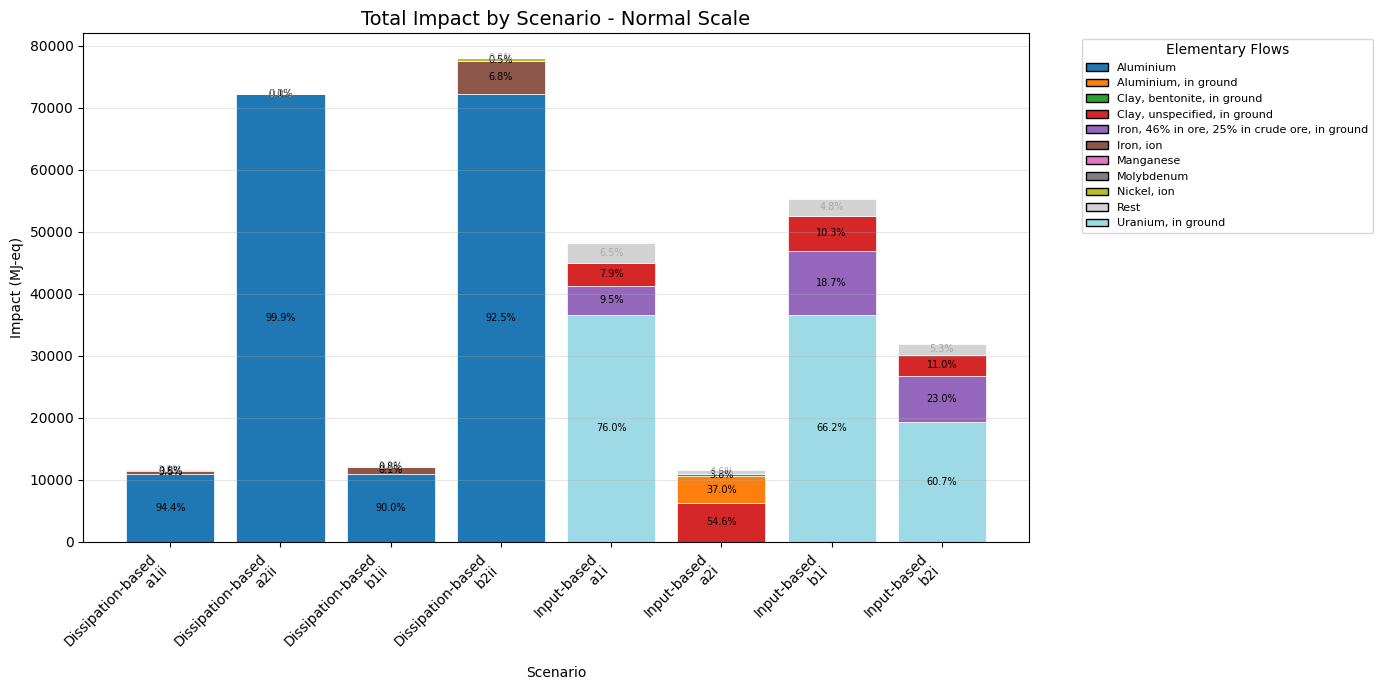

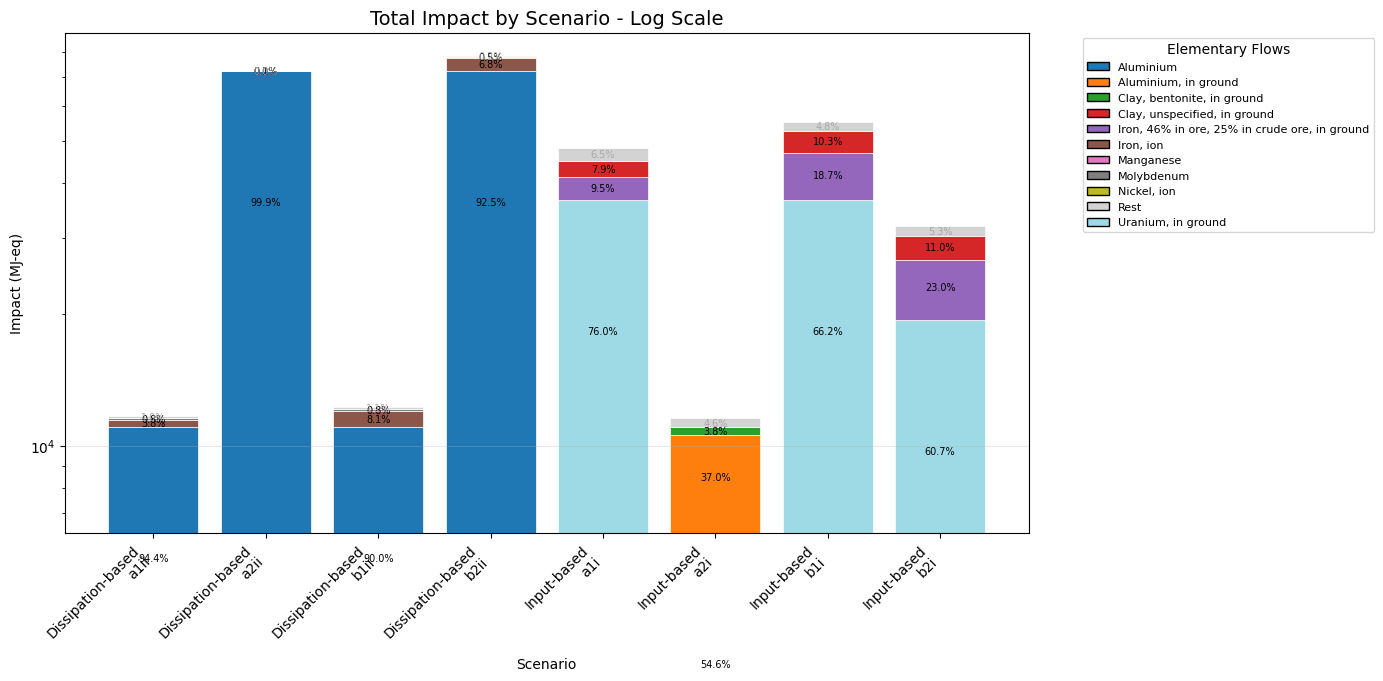

Top 3 contributors and Rest for each scenario:

Dissipation-based - a1ii: Total = 11673.86 MJ-eq
  Aluminium                               :  94.4%
  Iron, ion                               :   3.8%
  Molybdenum                              :   0.8%
  Rest                                    :   1.0%

Dissipation-based - a2ii: Total = 72273.64 MJ-eq
  Aluminium                               :  99.9%
  Molybdenum                              :   0.1%
  Manganese                               :   0.0%
  Rest                                    :   0.0%

Dissipation-based - b1ii: Total = 12240.51 MJ-eq
  Aluminium                               :  90.0%
  Iron, ion                               :   8.1%
  Molybdenum                              :   0.8%
  Rest                                    :   1.1%

Dissipation-based - b2ii: Total = 78121.19 MJ-eq
  Aluminium                               :  92.5%
  Iron, ion                               :   6.8%
  Nickel, ion                          

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re
from matplotlib.patches import Patch

# Define paths
results_dir = r"C:\Users\louis\.github\Exergy-Ore-Grade-Decrease-Model\results"
file_pattern = r"market_for_electricity_high_voltage_\d+_CERC_(Input-based|Dissipation-based)_([a-z0-9]+)\.csv"

# Find and categorize files
files = []
for f in os.listdir(results_dir):
    match = re.match(file_pattern, f)
    if match:
        category = match.group(1)
        identifier = match.group(2)
        files.append((category, identifier, f))

# Sort by category then identifier
files.sort(key=lambda x: (x[0], x[1]))

# First pass: collect all flows that appear in top 3 of any scenario
all_top_flows = set(['Rest'])  # Start with Rest
file_data = []

for category, identifier, filename in files:
    filepath = os.path.join(results_dir, filename)
    df = pd.read_csv(filepath)
    total = df['amount'].sum()
    flow_amounts = df.groupby('flow')['amount'].sum()
    top3 = flow_amounts.nlargest(3)
    all_top_flows.update(top3.index)
    file_data.append((category, identifier, filepath, df, total, flow_amounts, top3))

# Assign consistent colors: only to flows that are in top 3 somewhere
flow_to_color = {}
colors = plt.cm.tab20(np.linspace(0, 1, len(all_top_flows)))
for i, flow in enumerate(sorted(all_top_flows)):
    if flow != 'Rest':
        flow_to_color[flow] = colors[i % len(colors)]
flow_to_color['Rest'] = 'lightgray'

# Prepare data for stacked bars - only top 3 + Rest for each scenario
categories = []
stack_data = []

for category, identifier, filepath, df, total, flow_amounts, top3 in file_data:
    categories.append(f"{category}\n{identifier}")

    segments = []
    for flow, amount in top3.items():
        pct = (amount / total) * 100
        segments.append({
            'flow': flow,
            'amount': amount,
            'color': flow_to_color[flow],
            'percentage': pct
        })

    rest_amount = total - top3.sum()
    rest_pct = (rest_amount / total) * 100
    segments.append({
        'flow': 'Rest',
        'amount': rest_amount,
        'color': flow_to_color['Rest'],
        'percentage': rest_pct
    })

    stack_data.append(segments)

# Create both normal and log scale figures
for scale_type in ['normal', 'log']:
    fig, ax = plt.subplots(figsize=(14, 7))

    x = np.arange(len(categories))
    bar_width = 0.8
    bottom = np.zeros(len(categories))

    for i, segments in enumerate(stack_data):
        current_bottom = bottom[i]
        for seg in segments:
            if seg['amount'] > 0:
                ax.bar(x[i], seg['amount'], width=bar_width,
                       bottom=current_bottom, color=seg['color'], edgecolor='white', linewidth=0.5)
                current_bottom += seg['amount']

                # Add percentage text in the middle of the segment
                y_pos = current_bottom - seg['amount']/2
                text_color = 'black' if seg['flow'] != 'Rest' else 'darkgray'
                ax.text(x[i], y_pos, f"{seg['percentage']:.1f}%",
                       ha='center', va='center', fontsize=7, color=text_color)

        bottom[i] = current_bottom

    if scale_type == 'log':
        ax.set_yscale('log')
        ax.set_title('Total Impact by Scenario - Log Scale', fontsize=14)
    else:
        ax.set_title('Total Impact by Scenario - Normal Scale', fontsize=14)

    ax.set_ylabel('Impact (MJ-eq)')
    ax.set_xlabel('Scenario')
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

    # Create legend with only top flows + Rest
    legend_elements = [Patch(facecolor=flow_to_color[flow], label=flow, edgecolor='black')
                      for flow in sorted(all_top_flows)]
    ax.legend(handles=legend_elements, title='Elementary Flows',
             bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    plt.tight_layout()
    plt.savefig(f"results/stacked_bar_{scale_type}.svg", dpi=300)
    plt.show()

# Print detailed breakdown
print("Top 3 contributors and Rest for each scenario:")
for category, identifier, filepath, df, total, flow_amounts, top3 in file_data:
    print(f"\n{category} - {identifier}: Total = {total:.2f} MJ-eq")
    for flow, amount in top3.items():
        pct = (amount / total) * 100
        print(f"  {flow:40s}: {pct:>5.1f}%")
    rest_pct = ((total - top3.sum()) / total) * 100
    print(f"  {'Rest':40s}: {rest_pct:>5.1f}%")


# ⚖️ Restorative Perspective (similar to Egalitarian cultural perspective)

## Extract ERC data

In [458]:
# Build the Valero rarity dictionary from local input data
valero_constants_csv = "inputs/valero-constants.csv"
valero_df = pd.read_csv(valero_constants_csv)
valero_df.columns = ['name', 'k(x=xm)', 'MW', 'xm[kg/kg]', 'ERC[MJ/kg]']

# Extract an elemental name from the raw mineral/material name
# Examples: "Aluminium - Bauxite (Gibbsite)" -> "Aluminium"; "Antimony (Stibnite)" -> "Antimony"
def extract_metal_base_name(raw_name):
    # Clean the raw name using the existing chemical name cleaner
    base = clean_chemical_name(raw_name)

    # Drop mineral-specific qualifiers after hyphens or before parentheses
    base = base.split('(')[0].split('-')[0].strip()
    base = re.sub(r"\s+ore$|\s+rock$", "", base, flags=re.IGNORECASE).strip()
    if not base:
        return None

    candidates = [base]
    if ' ' in base:
        candidates.append(base.split()[0])

    for candidate in candidates:
        try:
            elem = element(candidate)
            return elem.symbol
        except Exception:
            pass

    base_lower = base.lower()
    if 'aluminium' in base_lower or 'bauxite' in base_lower:
        return 'Al'
    if 'barite' in base_lower:
        return 'Ba'
    if 'fluorite' in base_lower:
        return 'Ca'
    if 'graphite' in base_lower:
        return 'C'
    if 'gypsum' in base_lower or 'lime' in base_lower:
        return 'Ca'
    if 'magnesite' in base_lower:
        return 'Mg'
    if 'phosphate' in base_lower or 'apatite' in base_lower:
        return 'P'
    if 'wolfram' in base_lower or 'scheelite' in base_lower:
        return 'W'
    if 'chalcopyrite' in base_lower:
        return 'Cu'
    if 'linnaeite' in base_lower:
        return 'Co'
    if 'stibnite' in base_lower:
        return 'Sb'
    if 'arsenopyrite' in base_lower:
        return 'As'
    if 'monazite' in base_lower:
        return 'Ce'
    if 'hematite' in base_lower:
        return 'Fe'
    if 'argentite' in base_lower:
        return 'Ag'
    if 'galena' in base_lower:
        return 'Pb'
    if 'spodumene' in base_lower:
        return 'Li'
    if 'beryl' in base_lower:
        return 'Be'
    if 'cassiterite' in base_lower:
        return 'Sn'
    if 'bastnaesite' in base_lower or 'ree' in base_lower:
        return 'REE'
    if 'garnierite' in base_lower:
        return 'Ni'
    if 'ferrocolumbite' in base_lower:
        return 'Nb'
    if 'sphalerite' in base_lower:
        return 'Zn'
    if 'cinnabar' in base_lower:
        return 'Hg'
    if 'pgm' in base_lower:
        return 'PGMs (average)'
    return None

valero_rarity_data = {}
valero_mapping = []
skipped = []
for _, row in valero_df.iterrows():
    raw_name = row['name']
    erc_value = row['ERC[MJ/kg]']
    symbol = extract_metal_base_name(raw_name)
    if symbol is not None and pd.notna(erc_value):
        valero_rarity_data[symbol] = float(erc_value)
        valero_mapping.append((raw_name, symbol, float(erc_value)))
    else:
        skipped.append(raw_name)
        print(f"Skipping unmapped Valero entry: {raw_name}")

print("\nMapped Valero entries:")
for raw_name, symbol, erc in valero_mapping:
    print(f"  {raw_name} -> {symbol} -> {erc}")

if skipped:
    print("\nSkipped Valero entries:")
    for raw_name in skipped:
        print(f"  {raw_name}")

ree_elements = ["Sc", "Y", "La", "Ce", "Pr", "Nd", "Pm", "Sm", "Eu", "Gd", "Tb", "Dy", "Ho", "Er", "Tm", "Yb", "Lu"]
pgm_elements = ["Pt", "Pd", "Rh", "Ru", "Ir", "Os"]

if 'REE' in valero_rarity_data:
    for elem in ree_elements:
        if elem not in valero_rarity_data:
            valero_rarity_data[elem] = valero_rarity_data['REE']

if 'PGMs (average)' in valero_rarity_data:
    for elem in pgm_elements:
        if elem not in valero_rarity_data:
            valero_rarity_data[elem] = valero_rarity_data['PGMs (average)']

print(f"Loaded {len(valero_rarity_data)} Valero rarity entries from {valero_constants_csv}")


Mapped Valero entries:
  Aluminium - Bauxite (Gibbsite) -> Al -> 627.0
  Antimony (Stibnite) -> Sb -> 474.0
  Arsenic (Arsenopyrite) -> As -> 400.0
  Barite -> Ba -> 38.0
  Beryllium (Beryl) -> Be -> 253.0
  Bismuth (Bismuthinite) -> Bi -> 489.0
  Cadmium (Greenockite) -> Cd -> 5900.0
  Cerium (Monazite) -> Ce -> 97.0
  Chromium (Chromite) -> Cr -> 5.0
  Cobalt (Linnaeite) -> Co -> 10900.0
  Copper (Chalcopyrite) -> Cu -> 292.0
  Fluorite -> Ca -> 183.0
  Gadolinium-Monazite -> Gd -> 478.0
  Gallium (in Bauxite) -> Ga -> 145000.0
  Germanium (in Zinc) -> Ge -> 23700.0
  Gold -> Au -> 553000.0
  Graphite -> C -> 20.0
  Gypsum -> Ca -> 15.0
  Hafnium -> Hf -> 21800.0
  Indium (in Zinc) -> In -> 361000.0
  Iron ore (Hematite) -> Fe -> 18.0
  Lanthanum-Monazite -> La -> 39.0
  Lead (Galena) -> Pb -> 37.0
  Lime -> Ca -> 3.0
  Lithium (Spodumene) -> Li -> 546.0
  Magnesite (from ocean) -> Mg -> 136.0
  Manganese (Pyrolusite) -> Mn -> 16.0
  Mercury (Cinnabar) -> Hg -> 28300.0
  Molybdenum 

In [ ]:

rows = []
for flow in biosphere_db:
    flow_dict = flow.as_dict()
    if 'categories' in flow_dict:
        flow_dict['categories'] = ", ".join(flow_dict['categories'])
    rows.append(flow_dict)

biosphere_flows_df = pd.DataFrame(rows)
os.makedirs("results", exist_ok=True)
# biosphere_flows_df.to_csv("results/EI_biosphere_flows.csv", index=False)
# print("✅ Exported ecoinvent biosphere flows to results/EI_biosphere_flows.csv")

✅ Exported ecoinvent biosphere flows to results/EI_biosphere_flows.csv


In [460]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
lci_strategy = "input-based"  # or "dissipation-based"
method_data = []
extra_info = []
not_found = []
not_emission = []

for flow in biosphere_db:
    cf = None
    parts = None
    if lci_strategy == "input-based":
        if isinstance(flow.get('categories'), tuple) and len(flow['categories']) > 0 and \
        flow['unit'].lower() == 'kilogram' and flow['categories'][0].lower() == 'natural resource':
        
            flow_name_cleaned = clean_chemical_name(flow['name'])
            sleep(0.3)
            for attempt in range(3):
                try:
                    compound = pcp.get_compounds(flow_name_cleaned, 'name')
                    if compound:
                        c = compound[0]
                        mf = c.molecular_formula
                        mw = c.molecular_weight
                        parts = chem_comp(mf)

                        if len(parts) == 1:
                            if has_elem(parts, valero_rarity_data):
                                cf = valero_rarity_data.get(parts[0][0])
                                print(f"The CF of the pure metal {mf} is {cf}")
                            else:
                                print(f"{flow['name']} does not contain any scoped metal.")
                        elif len(parts) > 1:
                            if has_elem(parts, valero_rarity_data):
                                cf = cf_calculator(valero_rarity_data, mw, parts)
                                print(f"The CF of the compound {mf} is {cf}")
                            else:
                                print(f"{flow['name']} does not contain any scoped metal.")
                        else:
                            print(f"No recognizable elements found in {flow['name']}")

                        if cf is not None:
                            method_data.append((flow.key, float(cf)))
                            extra_info.append([flow.key, flow['name'], flow_name_cleaned, mf, mw, float(cf)])
                        else:
                            extra_info.append([flow.key, flow['name'], flow_name_cleaned, mf, mw, None])
                    else:
                        print(f"Compound not found for: {flow['name']}")
                        not_found.append([flow.key, flow['name']])
                    break

                except PubChemHTTPError as e:
                    if "502" in str(e) and attempt < 2:
                        print(f"Server error for {flow_name_cleaned}. Retrying... ({attempt + 1}/3)")
                        time.sleep(2)
                    else:
                        print(f"Failed to fetch {flow_name_cleaned}: {e}")
                        not_found.append([flow.key, flow['name']])
                        break
        else:
            not_emission.append([flow.key, flow['name']])
            
    elif lci_strategy == "dissipation-based":
        if isinstance(flow.get('categories'), tuple) and len(flow['categories']) > 0 and \
        flow['unit'].lower() == 'kilogram' and flow['categories'][0].lower() != 'natural resource':
        
            flow_name_cleaned = clean_chemical_name(flow['name'])
            sleep(0.3)
            for attempt in range(3):
                try:
                    compound = pcp.get_compounds(flow_name_cleaned, 'name')
                    if compound:
                        c = compound[0]
                        mf = c.molecular_formula
                        mw = c.molecular_weight
                        parts = chem_comp(mf)

                        if len(parts) == 1:
                            if has_elem(parts, valero_rarity_data):
                                cf = valero_rarity_data.get(parts[0][0])
                                print(f"The CF of the pure metal {mf} is {cf}")
                            else:
                                print(f"{flow['name']} does not contain any scoped metal.")
                        elif len(parts) > 1:
                            if has_elem(parts, valero_rarity_data):
                                cf = cf_calculator(valero_rarity_data, mw, parts)
                                print(f"The CF of the compound {mf} is {cf}")
                            else:
                                print(f"{flow['name']} does not contain any scoped metal.")
                        else:
                            print(f"No recognizable elements found in {flow['name']}")

                        if cf is not None:
                            method_data.append((flow.key, float(cf)))
                            extra_info.append([flow.key, flow['name'], flow_name_cleaned, mf, mw, float(cf)])
                        else:
                            extra_info.append([flow.key, flow['name'], flow_name_cleaned, mf, mw, None])
                    else:
                        print(f"Compound not found for: {flow['name']}")
                        not_found.append([flow.key, flow['name']])
                    break

                except PubChemHTTPError as e:
                    if "502" in str(e) and attempt < 2:
                        print(f"Server error for {flow_name_cleaned}. Retrying... ({attempt + 1}/3)")
                        time.sleep(2)
                    else:
                        print(f"Failed to fetch {flow_name_cleaned}: {e}")
                        not_found.append([flow.key, flow['name']])
                        break
        else:
            not_emission.append([flow.key, flow['name']])
    else:
        print("wrong lci_strategy")

results_df = pd.DataFrame(method_data, columns=['flow_key', 'cf'])
info_df = pd.DataFrame(extra_info, columns=['flow_key', 'name', 'cleaned_name', 'formula', 'mw', 'cf'])
not_found_df = pd.DataFrame(not_found, columns=['flow_key', 'name'])
not_emission_df = pd.DataFrame(not_emission, columns=['flow_key', 'name'])

results_df.to_csv("results/PubChem_ERC_EI34.csv", index=False)
info_df.to_csv("results/PubChem_Info_EI34.csv", index=False)
not_found_df.to_csv("results/PubChem_NotFound_EI34.csv", index=False)
not_emission_df.to_csv("results/PubChem_NotEmission_EI34.csv", index=False)
print("✅ Saved Ecoinvent ERC outputs to the results/ folder")

The CF of the pure metal Ag is 7370.0
The CF of the pure metal Rh is 2700000.0
The CF of the pure metal Mn is 16.0
The CF of the pure metal Mo is 908.0
The CF of the pure metal Nd is 78.0
Cl is not included in the scope.
H is not included in the scope.
The CF of the compound Cl3H12KMgO6 is 105.47363505488572
The CF of the compound AlKO8Si3 is 154.5002304440772
Compound not found for: Coal, hard, unspecified, in ground
The CF of the compound BaO4S is 22.35925275290287
The CF of the pure metal Ag is 7370.0
The CF of the pure metal Gd is 478.0
The CF of the pure metal Cd is 5900.0
The CF of the pure metal Ni is 167.0
Xe is not included in the scope.
Xenon, in air does not contain any scoped metal.
The CF of the pure metal Au is 553000.0
Compound not found for: TiO2, 54% in ilmenite, 2.6% in crude ore, in ground
The CF of the pure metal Ni is 167.0
Compound not found for: Steatite, in ground
Server error for Gallium. Retrying... (1/3)
The CF of the pure metal Ga is 145000.0
B is not includ

In [463]:
method_name_tuple = (
    "Cumulative Exergy Replacement Cost",
    f"{lci_strategy.capitalize()}",
    f"ERC total: To Repurpose all dissipated flows as resources applied to {len(valero_rarity_data)}"
)
method_metadata = {
    'unit': 'MJ-Eq',
    'description': 'Exergy Replacement Cost for elementary flows based on Valero rarity values and PubChem molecular formulas.',
    'source': 'inputs/valero-constants.csv and PubChem',
    'version': '1.0',
    'num_cfs': len(method_data),
    'application': 'Elementary biosphere flows'
}

method_object = bd.Method(method_name_tuple)
method_object.register(**method_metadata)
method_object.write(method_data)

print(f"✅ Created method: {method_name_tuple}")
print(f"Method contains {len(method_data)} CF entries")

print("\n--- Available methods ---")
for m in bd.methods:
    print(m)

✅ Created method: ('Cumulative Exergy Replacement Cost', 'Input-based', 'ERC total: To Repurpose all dissipated flows as resources applied to 69')
Method contains 130 CF entries

--- Available methods ---
('ecoinvent-3.4', 'CML 2001', 'acidification potential', 'average European')
('ecoinvent-3.4', 'CML 2001', 'acidification potential', 'generic')
('ecoinvent-3.4', 'CML 2001', 'climate change', 'GWP 100a')
('ecoinvent-3.4', 'CML 2001', 'climate change', 'GWP 20a')
('ecoinvent-3.4', 'CML 2001', 'climate change', 'GWP 500a')
('ecoinvent-3.4', 'CML 2001', 'climate change', 'lower limit of net GWP')
('ecoinvent-3.4', 'CML 2001', 'climate change', 'upper limit of net GWP')
('ecoinvent-3.4', 'CML 2001', 'eutrophication potential', 'average European')
('ecoinvent-3.4', 'CML 2001', 'eutrophication potential', 'generic')
('ecoinvent-3.4', 'CML 2001', 'freshwater aquatic ecotoxicity', 'FAETP 100a')
('ecoinvent-3.4', 'CML 2001', 'freshwater aquatic ecotoxicity', 'FAETP 20a')
('ecoinvent-3.4', 'CM

In [464]:
if "ecoinvent-3.4-cutoff" in bd.databases:
    try:
        my_db = bd.Database("ecoinvent-3.4-cutoff")
        results = my_db.search("iron production")
        print(f"Found {len(results)} iron-related activities")
        for activity in results[:10]:
            print(f"Region: {activity['location']}, Name: {activity['name']}, Code: {activity['code']}")
    except Exception as e:
        print(f"Search failed: {e}")
else:
    print("Database ecoinvent-3.4-cutoff not available in this Brightway project.")

Found 25 iron-related activities
Region: GLO, Name: market for iron(III) chloride, without water, in 14% iron solution state, Code: a54978781257bff94613c03f3d2780fa
Region: GLO, Name: market for iron(III) sulfate, without water, in 12.5% iron solution state, Code: 26822caa5afb16a5003cebd655562926
Region: GLO, Name: market for iron(III) chloride, without water, in a 12% iron solution state, Code: 5e8d251ef05373bd5e94ade8cf92e9c7
Region: RoW, Name: market for wastewater from pig iron production, Code: c40a282af7cd853cfdf411b123285267
Region: CA-QC, Name: iron(III) chloride production, without water, in 14% iron solution state, Code: 6aab39ddd795c3c17495caa45e8e6252
Region: CA-QC, Name: iron(III) chloride production, without water, in 12% iron solution state, Code: aa1548acec01e9d9a6111f27a9273e53
Region: RoW, Name: iron(III) chloride production, without water, in 14% iron solution state, Code: 6df9490e5a577ae73d7294fe43d55d57
Region: RoW, Name: iron(III) chloride production, without wate

In [465]:
if "ecoinvent-3.4-cutoff" in bd.databases:
    try:
        my_act = bd.Database("ecoinvent-3.4-cutoff").get("18107bc7b3e28650e3fd8cf16da9aed9")
        lca = bc.LCA({my_act: 1}, method_name_tuple)
        lca.lci()
        lca.lcia()
        print(f"Total Impact for activity {my_act['name']}: {lca.score}")
    except Exception as e:
        print(f"Could not run example LCA: {e}")
else:
    print("Skipping example LCA because ecoinvent-3.4-cutoff is not loaded.")

Total Impact for activity pig iron production: 30.173153003682415
